# Statistics for Machine Learning 

Today, we explore **statistics**, the heartbeat of machine learning. Statistics helps us listen to data, spot patterns, handle uncertainty, and build better models. This notebook explains key concepts step-by-step with simple code and real-world-style examples.

## 1. Outlier Detection
Outliers are the **weird points** that don’t fit with the rest of the data. We’ll use a **housing dataset** (price vs size) and find outliers using:
- **Visual inspection**
- **Z-score method**
- **IQR method**

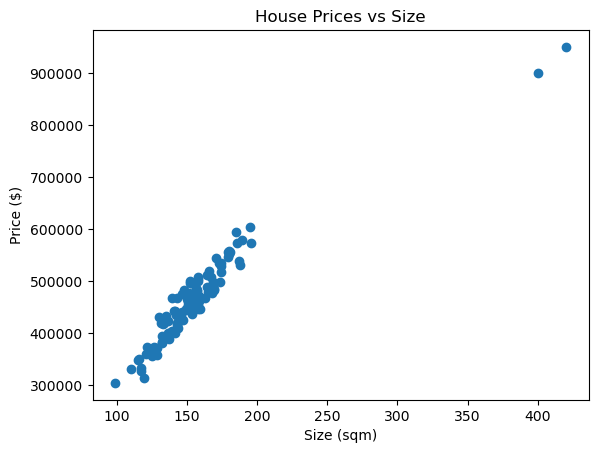

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generate synthetic housing data
np.random.seed(0)
sizes = np.random.normal(150, 20, 100)
prices = sizes * 3000 + np.random.normal(0, 20000, 100)

# Add outliers
sizes = np.append(sizes, [400, 420])
prices = np.append(prices, [900000, 950000])

# Plot
plt.scatter(sizes, prices)
plt.title("House Prices vs Size")
plt.xlabel("Size (sqm)")
plt.ylabel("Price ($)")
plt.show()

In [24]:
# Z-score method
from scipy.stats import zscore

data = pd.DataFrame({'Size': sizes, 'Price': prices})
z_scores = np.abs(zscore(data))
outliers = (z_scores > 3).any(axis=1)
print("Outliers detected (Z-score):")
print(data[outliers])

Outliers detected (Z-score):
      Size     Price
100  400.0  900000.0
101  420.0  950000.0


In [26]:
# IQR method
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
outliers_iqr = ((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).any(axis=1)
print("Outliers detected (IQR):")
print(data[outliers_iqr])

Outliers detected (IQR):
      Size     Price
100  400.0  900000.0
101  420.0  950000.0


## 2. Regression Coefficients
We’ll fit a **linear regression** to the housing data to see how house price changes with size.

In [29]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
X = data[['Size']]
y = data['Price']
model.fit(X, y)
print(f"Regression Coefficient (slope): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")

Regression Coefficient (slope): 2122.66
Intercept: 132729.53


## 3. Correlation Coefficients
Let’s calculate the **correlation** between house size and price.

In [32]:
corr = data['Size'].corr(data['Price'])
print(f"Correlation Coefficient: {corr:.2f}")

Correlation Coefficient: 0.94


## 4. Descriptive Statistics
We’ll describe the **spread and shape** of house sizes.

In [35]:
print(data['Size'].describe())
from scipy.stats import skew
print(f"Skewness: {skew(data['Size']):.2f}")

count    102.000000
mean     156.270745
std       41.286883
min       98.940204
25%      137.590920
50%      152.485871
75%      165.467544
max      420.000000
Name: Size, dtype: float64
Skewness: 4.55


## 5. Scatterplots
We’ll plot house size vs price again with a regression line.

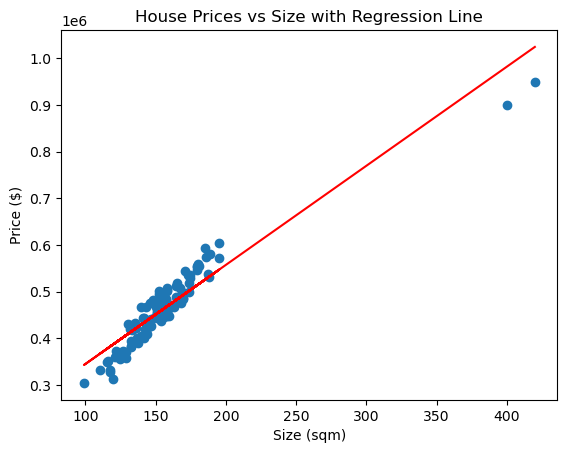

In [38]:
plt.scatter(sizes, prices)
plt.plot(sizes, model.predict(X), color='red')
plt.title("House Prices vs Size with Regression Line")
plt.xlabel("Size (sqm)")
plt.ylabel("Price ($)")
plt.show()

## 6. Maximum Likelihood Estimation (MLE)
We flip a coin 10 times and get 7 heads. What's the **MLE estimate** of the probability of heads?

In [41]:
heads = 7
tosses = 10
mle_p = heads / tosses
print(f"MLE estimate of P(Heads): {mle_p:.2f}")

MLE estimate of P(Heads): 0.70


## 7. Bootstrapping
We estimate the **confidence interval** of the mean house size using bootstrapping.

In [44]:
means = []
for _ in range(1000):
    sample = data['Size'].sample(frac=1, replace=True)
    means.append(sample.mean())

ci_lower = np.percentile(means, 2.5)
ci_upper = np.percentile(means, 97.5)
print(f"95% Confidence Interval for Mean Size: ({ci_lower:.2f}, {ci_upper:.2f})")

95% Confidence Interval for Mean Size: (149.24, 165.45)


## 8. Impact of Removing Outliers
We remove outliers and refit the regression to see the impact.

In [47]:
clean_data = data[~outliers]
model_clean = LinearRegression()
model_clean.fit(clean_data[['Size']], clean_data['Price'])
print(f"Cleaned Regression Coefficient: {model_clean.coef_[0]:.2f}")
print(f"Cleaned Intercept: {model_clean.intercept_:.2f}")

Cleaned Regression Coefficient: 3114.70
Cleaned Intercept: -15701.70


## Conclusion
Statistics is the **language of uncertainty**. From spotting outliers to estimating parameters, these tools help machine learning practitioners build **smarter models** and avoid being misled by messy data.